# Baseline Model Performance

## Objective
To evaluate classification performance using all 30 original features
without applying dimensionality reduction.

This will serve as a reference for comparison with feature reduction methods.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df = pd.read_csv(r"C:\ML PROJECT\Dimensionality-Reduction-Classification-Study\data\raw_data\breast_cancer.csv")

X = df.drop("target", axis=1)
y = df["target"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

In [6]:
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

In [7]:
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,F1 Score,ROC-AUC
0,Random Forest,0.956140,0.958904,0.965517,0.993882
1,Decision Tree,0.912281,0.955882,0.928571,0.915675
2,SVM,0.982456,0.986111,0.986111,0.995040
3,Naive Bayes,0.929825,0.944444,0.944444,0.986772
4,KNN,0.956140,0.958904,0.965517,0.978836


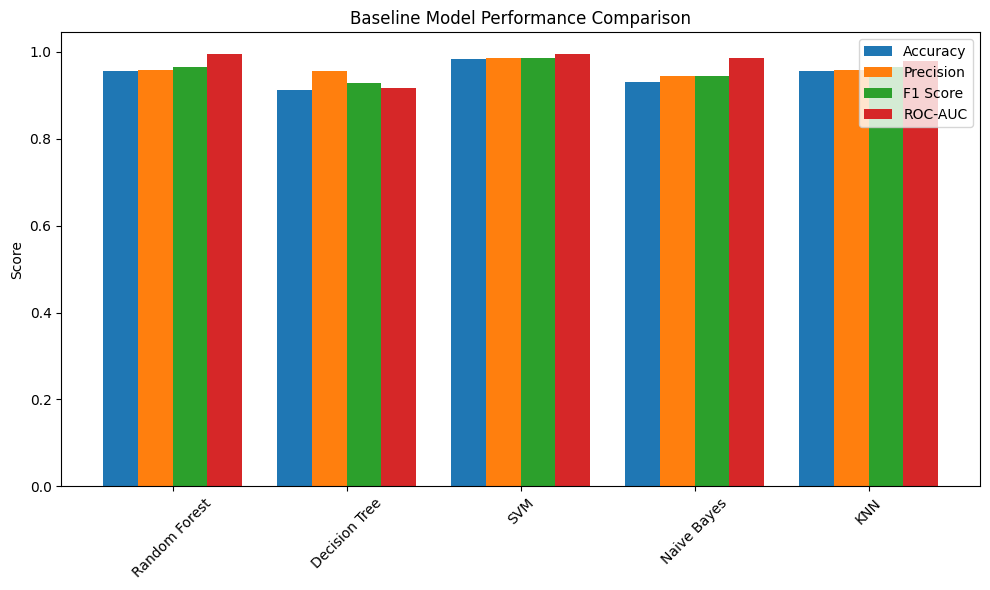

In [9]:
import numpy as np
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "F1 Score", "ROC-AUC"]
x = np.arange(len(results_df["Model"]))
width = 0.2

plt.figure(figsize=(10,6))

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, results_df[metric], width, label=metric)

plt.xticks(x + width*1.5, results_df["Model"], rotation=45)
plt.ylabel("Score")
plt.title("Baseline Model Performance Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
results_df.to_csv(r"C:\ML PROJECT\Dimensionality-Reduction-Classification-Study\results\baseline_results.csv", index=False)